# Chapter 4. The typical order

**Week 1, Monday. Chapter 4 of 6: what does a typical Kalpa order look like, and which
"typical" is honest?**

**The need.** Marketing's case for Rs 12 crore values every new customer by the order they
will place. Meera wants to know what that order is worth, and Anand has said how he will read
the answer:

> Meera: "What does a typical order look like?"
> Anand: "No averages. One business customer can move an average."

| | |
|---|---|
| The metric at stake | The typical order, the value per order that an acquisition payback is priced on |
| Who asks | Meera and the marketing lead for the payback; Anand Iyer, who has already warned against averages |
| What a wrong number costs | A first order valued eight times too high makes Rs 12 crore look cheap and the payback look short |
| A real company with the same question | Blinkit reported a net average order value of Rs 518 for the quarter to June 2026 (MediaNama on Eternal's results, 24 July 2026). A reported AOV is a mean, the right number for totals across millions of orders; it is the wrong one to describe one shopper's basket when a few very large orders sit in the same file. |
| In the dossier (`study-notes/C2_W01_D01_domain_retail_STUDENT.md`) | Section 5, average order value and basket size: an average compares only with its own kind of order |

Chapter 3 filled the customer branches: 23 customers, 1.30 orders each, 7 came back, and the
tree multiplies back through an AOV of Rs 18,160. This chapter asks whether Rs 18,160
describes an order anybody at Kalpa would recognise.

> **Kavya's review.** When you tell Meera what a typical order is worth, tell her which middle
> you used and why. If one order can move your number, it describes that order and not the
> business.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

amounts = [int(order["amount"]) for order in ORDERS]
mean = sum(amounts) / len(amounts)
print(len(amounts), "amounts; the mean, chapter 2's AOV, is", kit.rupees(mean))

30 amounts; the mean, chapter 2's AOV, is Rs 18,160


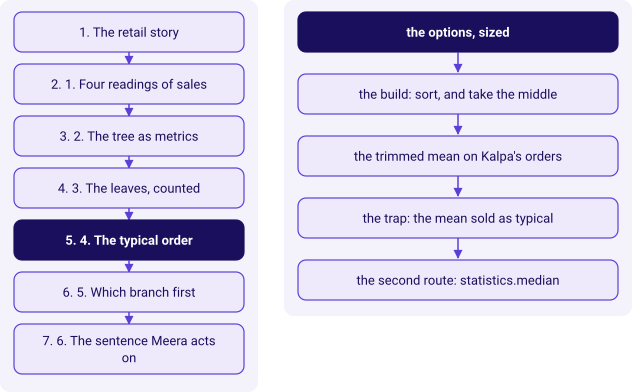

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=4, show=False),
    kit.vflow(['the options, sized', 'the build: sort, and take the middle', "the trimmed mean on Kalpa's orders", 'the trap: the mean sold as typical', 'the second route: statistics.median'], lit=0, show=False),
)

## The options

Four middles a team could report. The sizing column says how far each moves when one
**invented** Rs 90,000 order joins five invented orders of Rs 1,900 to Rs 2,600, which is the
test Anand set.

| Option | Work on this file | Moves with one large order | Right call when |
|---|---|---|---|
| A. The mean, total over count | one sum | by every rupee of the large order | totals and forecasts must multiply back |
| B. The median, the middle of the sorted amounts | a sort of 30 | by one place in the sort | the question is "what does a typical order look like" |
| C. A trimmed mean, dropping the top and bottom order | a sort and a sum | little, if the rule trims enough | there is a stated rule for how many to drop |
| D. A mean per customer type | a grouping | none within a type | the types are known and each gets its own plan |

**The best-fit call.** B for the typical order, with A reported beside it for the total, since
the gap between them is itself a finding. **What would change it:** if marketing prices the
payback per customer type, D answers better; that grouping is the afternoon's second case.

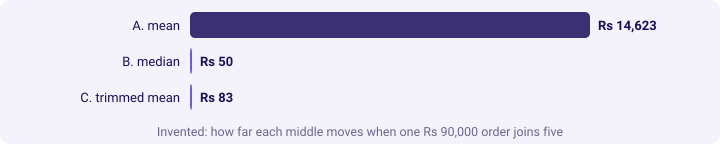

In [3]:
invented = [1900, 2100, 2300, 2400, 2600]                  # invented orders, for the sizing only
plus = sorted(invented + [90000])                          # one invented large order added
def middle(xs):
    xs = sorted(xs); n = len(xs)
    return xs[n // 2] if n % 2 else (xs[n // 2 - 1] + xs[n // 2]) / 2
def trimmed(xs):
    xs = sorted(xs)[1:-1]; return sum(xs) / len(xs)
moves = [("A. mean", sum(plus) / 6 - sum(invented) / 5),
         ("B. median", middle(plus) - middle(invented)),
         ("C. trimmed mean", trimmed(plus) - trimmed(invented))]
kit.bars([(n, round(m)) for n, m in moves], fmt=kit.rupees, lit=(0,),
         title="Invented: how far each middle moves when one Rs 90,000 order joins five")
kit.check("the invented median moves Rs 50", round(moves[1][1]) == 50)
kit.check("the invented mean moves by more than Rs 14,000", moves[0][1] > 14000)

## 1. The build: sort, and take the middle

The median has half the orders below it and half above. With 30 orders there are two middle
values, the 15th and 16th in size order, and the median is halfway between them.

**Predict before you run.** What is the median order?

- a) About Rs 2,200.
- b) Rs 18,160.
- c) Rs 9,080, half the mean.
- d) Rs 2,300, the 16th order in size order.

the two middle orders: Rs 2,110 and Rs 2,300
median: Rs 2,205 | mean: Rs 18,160 | the mean is 8.2 times the median


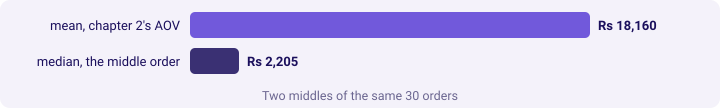

In [4]:
ranked = sorted(amounts)
median = (ranked[14] + ranked[15]) / 2
print("the two middle orders:", kit.rupees(ranked[14]), "and", kit.rupees(ranked[15]))
print("median:", kit.rupees(median), "| mean:", kit.rupees(mean), f"| the mean is {mean / median:.1f} times the median")
kit.bars([("mean, chapter 2's AOV", round(mean)), ("median, the middle order", round(median))],
         fmt=kit.rupees, lit=(1,), title="Two middles of the same 30 orders")
kit.check("the median is Rs 2,205", median == 2205)
kit.check("the mean is about eight times the median", 8 <= mean / median <= 8.5, f"{mean / median:.2f}")

**What happened.** The answer is a: Rs 2,205, about one eighth of the mean. Two middles that far
apart are a finding in themselves.

## 2. The trimmed mean on Kalpa's own orders

Option C in the table, run on the file: drop the smallest and the largest order and average
the other 28. It needs a rule for how many to drop, and it is the middle a spreadsheet user
reaches for first.

**Predict before you run.** Where does the trimmed mean of the 30 land?

- a) Near the mean of Rs 18,160.
- b) Halfway between the mean and the median.
- c) Within about Rs 100 of the median.
- d) Below every order in the file.

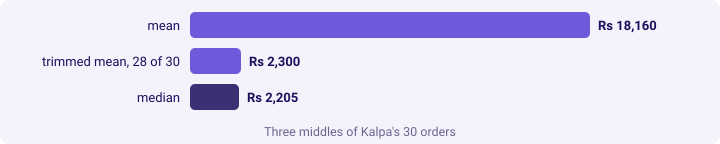

In [5]:
trimmed_kalpa = trimmed(amounts)
definitions = {"booked": {"delivered", "returned", "cancelled"}, "not cancelled": {"delivered", "returned"}}
middles = {}
for name, keep in definitions.items():
    kept = [int(o["amount"]) for o in ORDERS if o["status"] in keep]
    middles[name] = {"orders": len(kept), "mean": sum(kept) / len(kept), "median": middle(kept)}
kit.bars([("mean", round(mean)), ("trimmed mean, 28 of 30", round(trimmed_kalpa)), ("median", round(median))],
         fmt=kit.rupees, lit=(2,), title="Three middles of Kalpa's 30 orders")
kit.check("the trimmed mean lands within Rs 100 of the median", abs(trimmed_kalpa - median) < 100,
          kit.rupees(round(trimmed_kalpa)))
kit.check("dropping one order at each end moves the mean by more than Rs 15,000", mean - trimmed_kalpa > 15000)

**What happened.** The answer is c: Rs 2,300, beside the median of Rs 2,205. Here the trimming
rule happened to drop the one order that drags the mean; with two such orders it would drop
one and keep the other, which is why the median, which needs no rule, stays the call.

## 3. The trap: the mean sold as the typical order

Marketing's slide values each new customer's first order at the average order value.

**Predict before you run.** How many of the 30 orders are larger than the mean of Rs 18,160?

- a) About 15, half of them, since the mean is the middle.
- b) One of them.
- c) 29 of them, since the mean sits low.
- d) None of them.

**The plausible wrong answer.** The number as it appears on marketing's slide:

In [6]:
print("A typical Kalpa order:", kit.rupees(mean))
print("What each new customer's first order is worth, per the model:", kit.rupees(mean))

A typical Kalpa order: Rs 18,160
What each new customer's first order is worth, per the model: Rs 18,160


**Why it is wrong.** A typical order is one most orders look like. If nearly every order sits
below the mean, one order at the top is pulling the total, and the mean with it. Valued at
Rs 18,160, a new customer looks about eight times more valuable than the orders Kalpa takes,
and Rs 12 crore looks cheap. The check counts the orders on each side and draws every amount.

1 order above the mean, 29 below it


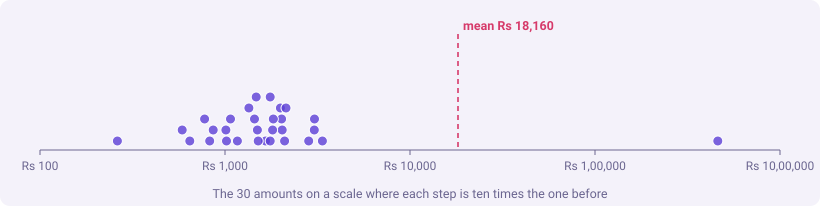

In [7]:
import math
above = sum(1 for a in amounts if a > mean)
print(above, "order above the mean,", len(amounts) - above, "below it")
kit.strip([math.log10(a) for a in amounts], markers=[("mean", math.log10(mean), "bad")],
          lo=2, hi=6, fmt=lambda v: kit.rupees(round(10 ** v)),
          title="The 30 amounts on a scale where each step is ten times the one before")
kit.check("exactly one order sits above the mean", above == 1)
kit.check("29 of 30 orders sit below the mean", len(amounts) - above == 29)

**What happened.** The answer is b. The dots pile up below Rs 5,000 while the mean stands far to
the right. The mean is correct arithmetic and a poor description of a Kalpa order.

**Your turn.** Find what sits at the top of the sort. Type these lines into the empty cell and
run it, then say in one sentence what kind of order the largest one must be:

```python
print("largest three:", ranked[-3:])
for order in ORDERS:
    if int(order["amount"]) == ranked[-1]:
        print(order)
```

The mechanism on a handful of **invented** numbers, which are not Kalpa orders: five invented
orders between Rs 1,900 and Rs 2,600, then one invented Rs 90,000 order added.

invented records,mean,median
five invented orders,"Rs 2,260","Rs 2,300"
"plus one invented Rs 90,000 order","Rs 16,883","Rs 2,350"


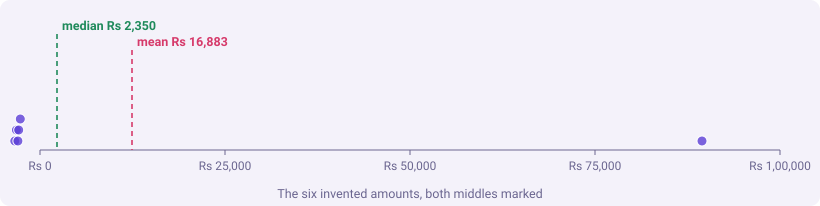

In [8]:
kit.table(["invented records", "mean", "median"],
          [("five invented orders", kit.rupees(sum(invented) / 5), kit.rupees(middle(invented))),
           ("plus one invented Rs 90,000 order", kit.rupees(round(sum(plus) / 6)), kit.rupees(middle(plus)))],
          caption="Invented numbers: what one large order does to each middle")
kit.strip(plus, markers=[("median", middle(plus), "good"), ("mean", round(sum(plus) / 6), "bad")],
          title="The six invented amounts, both middles marked")

**The fix, and what changed.** Report the build's median, Rs 2,205, as the typical order, with
the mean beside it for totals and the top order on its own line. A payback that credits each
new customer's order with Rs 18,160 overstates a typical order about eightfold. The honest
payback is built on the mean contribution of the customers the spend targets, with one-off large orders
set aside; chapter 5 sizes the plan that way.

## A second route: `statistics.median`

The standard library has the rule built in, including the even-count case. It must agree with
the hand-written middle on every definition.

In [9]:
import statistics
rows = []
for name, keep in definitions.items():
    kept = [int(o["amount"]) for o in ORDERS if o["status"] in keep]
    rows.append((name, kit.rupees(middles[name]["median"]), kit.rupees(statistics.median(kept))))
    kit.check(f"{name}: hand-written and library medians agree", statistics.median(kept) == middles[name]["median"])
kit.table(["definition", "sort and take the middle", "statistics.median"], rows,
          caption="Two routes to the median")

definition,sort and take the middle,statistics.median
booked,"Rs 2,205","Rs 2,205"
not cancelled,"Rs 2,100","Rs 2,100"


**When to switch.** Write the middle by hand once, so you know what the library does with an
even count; after that `statistics.median` is the route, and in Week 2 it becomes
`PERCENTILE_CONT(0.5)` in SQL and `.median()` in pandas. The switch that matters is between
middles: the mean comes back whenever a total has to reconcile.

> **Kavya's review.** Anand said "no averages" and you now know why. Put the median in the sentence, say the mean
> is eight times higher, and say one order does it.

### In the interview

**[S] Mean or median for order value, and why?** "The median when a few large orders can pull
the mean, which in retail is almost always, since occasional large buyers sit in the same file as
households. I report both with the count of orders above the mean, because the gap is itself a
finding: on Kalpa's quarter the mean was Rs 18,160, the median Rs 2,205, and 29 of 30 orders
sat below the mean. The mean keeps its job for totals, since mean times count gives revenue."

**[S] The mean order is Rs 18,160 and the median Rs 2,205; what do you tell the business about
its orders?** "That a typical order is about Rs 2,205 and one or a few very large orders lift
the mean to eight times that. I would sort, name what sits at the top, and ask whether it is a
different kind of customer that needs its own line in the plan. The median describes the
typical order; a plan or payback is built on the mean of the segment it targets, with the large
order on its own line."

**[D] Which middle would you put in a payback model, and what would make you change it?** "A
payback is a total over a customer's life, so it needs a mean, and the mean has to come from
the customers the spend targets: the consumer segment's mean contribution per customer over
the repeat window, with one-off large orders set aside. The median is what I quote as the
typical order beside it. I would change the segment, and so the mean, if the spend targeted
business buyers."

### Depth: how far one order has to go

The cell grows one **invented** order from Rs 2,600 to Rs 90,000 beside the same five invented
orders.

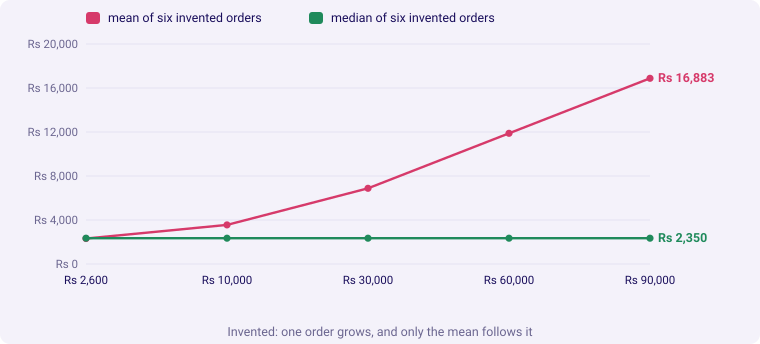

In [10]:
sizes = [2600, 10000, 30000, 60000, 90000]                 # the invented large order, growing
means = [round(sum(invented + [s]) / 6) for s in sizes]
medians = [round(middle(invented + [s])) for s in sizes]
kit.line([kit.rupees(s) for s in sizes], [("mean of six invented orders", means, "bad"),
                                          ("median of six invented orders", medians, "good")],
         fmt=kit.rupees, title="Invented: one order grows, and only the mean follows it")
kit.check("the invented median never passes Rs 2,500", max(medians) <= 2500)

## What this chapter established

What we now know,The evidence
"The mean is total over count, and one order drags it","Rs 18,160, 29 of 30 orders below"
The median is the typical order,"Rs 2,205, about one eighth of the mean"
A trimmed mean lands near the median on this file,"Rs 2,300 against Rs 2,205; the mean is Rs 18,160"
"A payback on Rs 18,160 overstates a typical order eightfold",the payback uses the targeted segment's mean


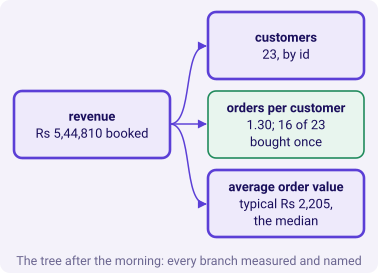

Next: chapter 5 asks which branch Meera opens first.


In [11]:
kit.table(["What we now know", "The evidence"],
          [("The mean is total over count, and one order drags it", "Rs 18,160, 29 of 30 orders below"),
           ("The median is the typical order", "Rs 2,205, about one eighth of the mean"),
           ("A trimmed mean lands near the median on this file", "Rs 2,300 against Rs 2,205; the mean is Rs 18,160"),
           ("A payback on Rs 18,160 overstates a typical order eightfold", "the payback uses the targeted segment's mean")],
          caption="Chapter 4: the typical order")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "23, by id", "kind": "known"},
    {"label": "orders per customer", "note": "1.30; 16 of 23 bought once", "kind": "good"},
    {"label": "average order value", "note": "typical Rs 2,205, the median", "kind": "known"}]},
    title="The tree after the morning: every branch measured and named")
kit.check_summary()
print("Next: chapter 5 asks which branch Meera opens first.")